In [29]:
import sys

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['omega_cdm', 'logA', 'h']

cosmo = AbacusSummit()
truth = {}
for p in params_toplot:
    try:
        truth[p] = cosmo[p]
    except:
        continue

def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples

plot_dir = Path('fits_QSO_zbins')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

## Blinded data

Removed no burn in
Removed no burn in
Removed no burn in


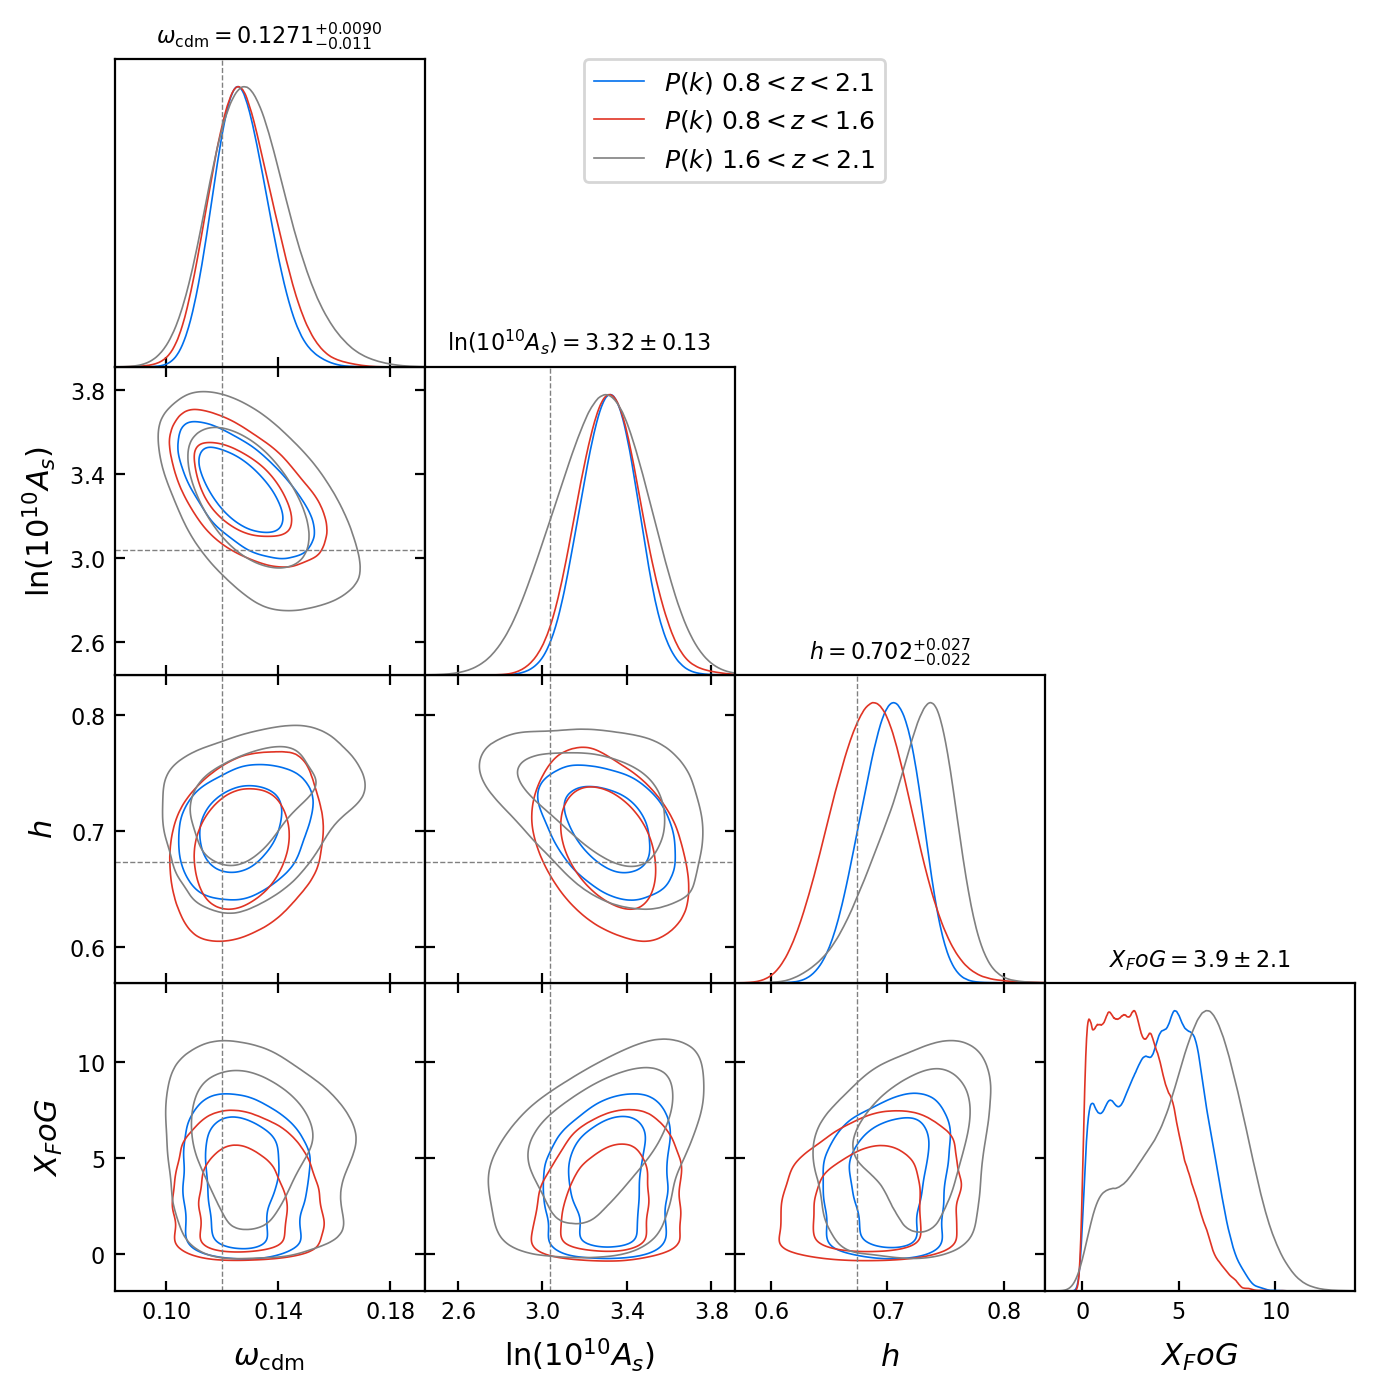

In [30]:
dirname = Path('/pscratch/sd/a/adematti/fits_QSO_zbins/data-dr2-v2/')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_QSO1-z0p8-2p1-GCcomb-S2-8ac82605/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ $0.8 < z < 2.1$')
samples.append(read_samples([dirname / f'cosmo-base_QSO-z0p8-1p6-GCcomb-S2-14a4eca4/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ $0.8 < z < 1.6$')
samples.append(read_samples([dirname / f'cosmo-base_QSO-z1p6-2p1-GCcomb-S2-85fbe58d/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ $1.6 < z < 2.1$')

for sample in samples:
    for name in sample.names(basename='X_FoG'):
        sample['X_FoG'] = sample[name]
plotting.plot_triangle(samples, params=params_toplot + ['X_FoG'], title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [8]:
(samples[2].mean('h') - samples[1].mean('h')) / (samples[2].std('h')**2 + samples[1].std('h')**2)**0.5

np.float64(0.7505678609166638)

Removed no burn in
Removed no burn in
Removed no burn in


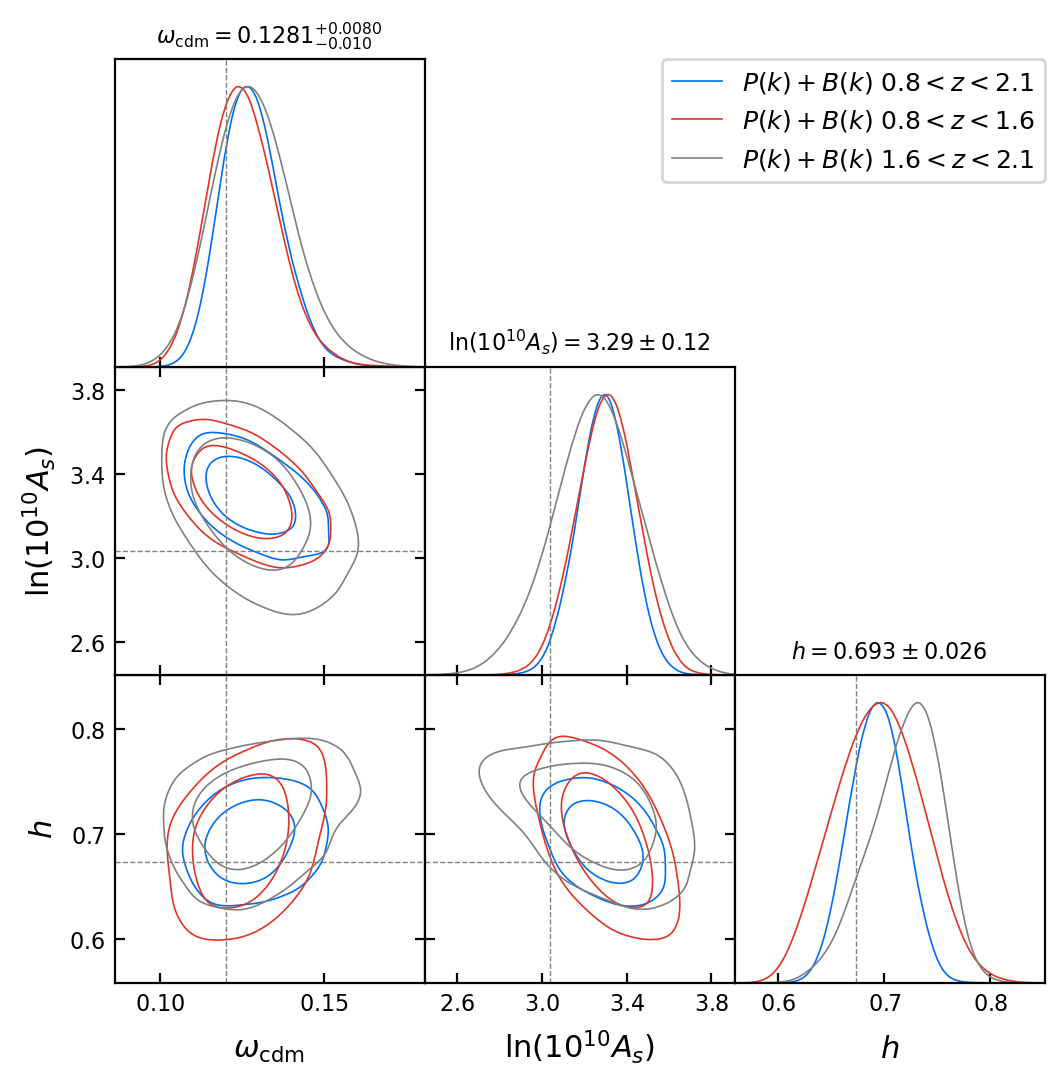

In [11]:
dirname = Path('/pscratch/sd/a/adematti/fits_QSO_zbins/data-dr2-v2/')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_QSO1-z0p8-2p1-GCcomb-S2+QSO1-z0p8-2p1-GCcomb-S3-04f13706/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k) + B(k)$ $0.8 < z < 2.1$')
samples.append(read_samples([dirname / f'cosmo-base_QSO-z0p8-1p6-GCcomb-S2+QSO-z0p8-1p6-GCcomb-S3-d37d3d4c/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k) + B(k)$ $0.8 < z < 1.6$')
samples.append(read_samples([dirname / f'cosmo-base_QSO-z1p6-2p1-GCcomb-S2+QSO-z1p6-2p1-GCcomb-S3-d41ba475/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k) + B(k)$ $1.6 < z < 2.1$')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()